In [1]:
from pathlib import Path
import sys
import pandas as pd

project_root = Path.cwd().parent
sys.path.append(str(project_root / "src"))

processed_dir = project_root / "data" / "processed"
results_root = project_root / "results"

paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

The PaySim dataset contains an additional rule-based variable, isFlaggedFraud. Since this variable could potentially act as a shortcut for fraud prediction, it was investigated on the training split before model training. The analysis showed that only 14 out of 5,749 fraud cases were flagged, corresponding to a coverage of 0.24%. Although the precision of the flag was 100%, its extremely low coverage indicates that it does not capture the majority of fraudulent transactions. Therefore, the variable was not considered a meaningful leakage source and was retained as a weak rule-based signal.

In [5]:
from test01 import (
    prepare_dataframes,
    build_preprocessor,
    build_xgb_pipeline,
    fit_model,
    evaluate_model,
    investigate_flagged_fraud,
)

In [6]:
# ── Cell 1: Run the investigation on the training split ───────────────────────
#
# We always investigate on the raw train split so the numbers reflect what
# the model actually sees during training.  paysim_train here is the raw CSV
# DataFrame — NOT the output of prepare_dataframes().
 
flagged_report = investigate_flagged_fraud(paysim_train, split_name="train")
 
# ── Cell 2: Quick sanity check — type distribution of all fraud ───────────────
#
# isFlaggedFraud only fires on TRANSFER transactions in PaySim.
# This cross-tab shows whether fraud is concentrated in that type, which
# contextualises the coverage number above.
 
fraud_by_type = (
    paysim_train.groupby("type")["isFraud"]
    .agg(total="count", fraud_count="sum")
    .assign(fraud_rate=lambda x: (x["fraud_count"] / x["total"] * 100).round(3))
    .sort_values("fraud_count", ascending=False)
)
print("\nFraud distribution by transaction type (train):")
print(fraud_by_type.to_string())


=== isFlaggedFraud analysis — TRAIN ===
Total fraud cases       : 5,749
Flagged transactions    : 14
Flagged AND fraud       : 14
Coverage  (flag recall) : 0.24%  — flag catches this share of all fraud
Precision (flag)        : 100.00%  — share of flagged txns that are fraud
Verdict                 : LOW COVERAGE — not a meaningful shortcut. Safe to keep.

Type breakdown of flagged transactions:
  4             flagged=14  fraud=14  (100.0% fraud)

Fraud distribution by transaction type (train):
        total  fraud_count  fraud_rate
type                                  
1     1566250         2883       0.184
4      373140         2866       0.768
0      979357            0       0.000
2       29102            0       0.000
3     1505985            0       0.000


In [19]:
paysim_train = pd.read_csv(processed_dir / "paysim_train.csv")
paysim_val = pd.read_csv(processed_dir / "paysim_val.csv")
paysim_test = pd.read_csv(processed_dir / "paysim_test.csv")

data = prepare_dataframes(paysim_train, paysim_val, paysim_test)

X_train = data["X_train"]
y_train = data["y_train"]
X_val = data["X_val"]
y_val = data["y_val"]
X_test = data["X_test"]
y_test = data["y_test"]

categorical_features = data["categorical_features"]
numeric_features = data["numeric_features"]
feature_cols = data["feature_cols"]

print("Features used:", feature_cols)
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("\nTrain class counts:")
print(y_train.value_counts())

Features used: ['type', 'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFlaggedFraud']
X_train shape: (4453834, 8)
X_val shape: (636262, 8)
X_test shape: (1272524, 8)

Train class counts:
isFraud
0    4448085
1       5749
Name: count, dtype: int64


In [20]:
preprocessor = build_preprocessor(numeric_features, categorical_features)
scale_pos_weight = compute_scale_pos_weight(y_train)

print("scale_pos_weight:", scale_pos_weight)

scale_pos_weight: 773.7145590537485


In [21]:
results_dir = results_root / "tabular_full_xgboost_none"
results_dir.mkdir(parents=True, exist_ok=True)

model_none = build_xgb_pipeline(
    preprocessor=preprocessor,
    imbalance_method="none",
)

model_none = fit_model(model_none, X_train, y_train)
print("Training finished.")

Training finished.


In [22]:
val_metrics_none, val_cm_none = evaluate_model(
    model_none, X_val, y_val, split_name="validation_none"
)
test_metrics_none, test_cm_none = evaluate_model(
    model_none, X_test, y_test, split_name="test_none"
)


=== VALIDATION_NONE ===
accuracy: 0.999730
precision: 0.973723
recall: 0.812424
f1: 0.885790
roc_auc: 0.999917
pr_auc: 0.961377

Confusion matrix:
[[635423     18]
 [   154    667]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999    635441
           1     0.9737    0.8124    0.8858       821

    accuracy                         0.9997    636262
   macro avg     0.9867    0.9062    0.9428    636262
weighted avg     0.9997    0.9997    0.9997    636262


=== TEST_NONE ===
accuracy: 0.999744
precision: 0.967353
recall: 0.829580
f1: 0.893185
roc_auc: 0.999789
pr_auc: 0.963444

Confusion matrix:
[[1270835      46]
 [    280    1363]]

Classification report:
              precision    recall  f1-score   support

           0     0.9998    1.0000    0.9999   1270881
           1     0.9674    0.8296    0.8932      1643

    accuracy                         0.9997   1272524
   macro avg     0.9836    0.9148    0.9465

In [23]:
threshold_results_none = search_thresholds(model_none, X_val, y_val)
threshold_results_none

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.768000,0.935445,0.843493,1000
1,0.15,0.839465,0.917174,0.876601,897
2,0.20,0.877069,0.903776,0.890222,846
3,0.25,0.912827,0.892814,0.902709,803
4,0.30,0.924649,0.881851,0.902743,783
5,0.35,0.944371,0.868453,0.904822,755
6,0.40,0.952186,0.848965,0.897618,732
7,0.45,0.964789,0.834348,0.894840,710
8,0.50,0.973723,0.812424,0.885790,685
9,0.55,0.975794,0.785627,0.870445,661


In [34]:
cost_df_none = compute_cost_table(threshold_results_none, y_val)
cost_df_none.head()

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.10,768,232,53,635209,0.768000,0.935445,0.843493,1000,2766000
1,0.15,753,144,68,635297,0.839465,0.917174,0.876601,897,3472000
2,0.20,742,104,79,635337,0.877069,0.903776,0.890222,846,4002000
3,0.25,733,70,88,635371,0.912827,0.892814,0.902709,803,4435000
4,0.30,724,59,97,635382,0.924649,0.881851,0.902743,783,4879500


In [33]:
best_threshold_none = float(cost_df_none.iloc[0]["threshold"])
best_threshold_none

0.1

In [35]:
tuned_metrics_none, tuned_cm_none = evaluate_with_threshold(model_none, X_test, y_test, best_threshold_none)
cost_summary_none = compute_expected_cost_from_cm(tuned_cm_none)

print(cost_summary_none)


Tuned threshold: 0.1
Precision: 0.7701433514582303
Recall: 0.9482653682288497
F1: 0.8499727223131478

Confusion matrix:
[[1270416     465]
 [     85    1558]]

Classification report:
              precision    recall  f1-score   support

           0     0.9999    0.9996    0.9998   1270881
           1     0.7701    0.9483    0.8500      1643

    accuracy                         0.9996   1272524
   macro avg     0.8850    0.9739    0.9249   1272524
weighted avg     0.9996    0.9996    0.9996   1272524

{'tp': 1558, 'fp': 465, 'fn': 85, 'tn': 1270416, 'expected_cost': 4482500}


## Save experiment outputs
Save the trained model, metrics, confusion matrices, threshold search results, and tuned evaluation outputs.

In [36]:
save_experiment_outputs(
    results_dir=results_dir,
    model=model_none,
    val_metrics=val_metrics_none,
    test_metrics=test_metrics_none,
    val_cm=val_cm_none,
    test_cm=test_cm_none,
    threshold_results=threshold_results_none,
    cost_df=cost_df_none,
    tuned_metrics=tuned_metrics_none,
    tuned_cm=tuned_cm_none,
    prefix="xgb_none",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_none


In [37]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['xgb_none_cost_results.csv',
 'xgb_none_metrics_summary.csv',
 'xgb_none_model.joblib',
 'xgb_none_test_confusion_matrix.csv',
 'xgb_none_test_metrics.json',
 'xgb_none_threshold_results.csv',
 'xgb_none_tuned_test_confusion_matrix.csv',
 'xgb_none_tuned_test_metrics.json',
 'xgb_none_validation_confusion_matrix.csv',
 'xgb_none_validation_metrics.json']

In [38]:
print(X_train.shape, X_val.shape, X_test.shape)
print(y_train.value_counts())
print(scale_pos_weight)

(4453834, 8) (636262, 8) (1272524, 8)
isFraud
0    4448085
1       5749
Name: count, dtype: int64
773.7145590537485


# XGBoost with scale_pos_weight
This section trains an XGBoost model with imbalance correction through `scale_pos_weight`, evaluates it on the validation and test sets, tunes the classification threshold on the validation set, and computes expected fraud-detection cost.

In [39]:
results_dir = results_root / "tabular_full_xgboost_weight"
results_dir.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:", results_dir)

Results will be saved to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_weight


## Build weighted XGBoost pipeline
The model uses the same train/validation/test split as previous experiments.
Imbalance is handled through the `scale_pos_weight` parameter.

In [40]:
xgb_model_weight = build_xgb_pipeline(
    preprocessor=preprocessor,
    imbalance_method="scale_pos_weight",
    scale_pos_weight=scale_pos_weight,
)

xgb_model_weight

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Train the model
Fit the weighted XGBoost model on the full training split.

In [41]:
xgb_model_weight = fit_model(xgb_model_weight, X_train, y_train)
print("Training finished.")

Training finished.


## Evaluate default threshold performance
First evaluate the model with the default classification threshold before threshold tuning.

In [42]:
val_metrics_weight, val_cm_weight = evaluate_model(
    xgb_model_weight,
    X_val,
    y_val,
    split_name="validation_weight"
)


=== VALIDATION_WEIGHT ===
accuracy: 0.996402
precision: 0.263835
recall: 0.998782
f1: 0.417409
roc_auc: 0.999911
pr_auc: 0.957481

Confusion matrix:
[[633153   2288]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982    635441
           1     0.2638    0.9988    0.4174       821

    accuracy                         0.9964    636262
   macro avg     0.6319    0.9976    0.7078    636262
weighted avg     0.9990    0.9964    0.9974    636262



In [43]:
test_metrics_weight, test_cm_weight = evaluate_model(
    xgb_model_weight,
    X_test,
    y_test,
    split_name="test_weight"
)


=== TEST_WEIGHT ===
accuracy: 0.996438
precision: 0.265422
recall: 0.995131
f1: 0.419070
roc_auc: 0.999820
pr_auc: 0.960959

Confusion matrix:
[[1266356    4525]
 [      8    1635]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982   1270881
           1     0.2654    0.9951    0.4191      1643

    accuracy                         0.9964   1272524
   macro avg     0.6327    0.9958    0.7086   1272524
weighted avg     0.9990    0.9964    0.9975   1272524



## Search thresholds on validation set
Predicted probabilities are converted into class predictions under different thresholds.
The goal is to find a threshold that reduces expected fraud-detection cost.

In [44]:
threshold_results_weight = search_thresholds(xgb_model_weight, X_val, y_val)
threshold_results_weight

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.113949,1.000000,0.204585,7205
1,0.15,0.136538,1.000000,0.240269,6013
2,0.20,0.156173,1.000000,0.270155,5257
3,0.25,0.174051,1.000000,0.296497,4717
4,0.30,0.191321,0.998782,0.321128,4286
5,0.35,0.209772,0.998782,0.346723,3909
6,0.40,0.227210,0.998782,0.370203,3609
7,0.45,0.244557,0.998782,0.392908,3353
8,0.50,0.263835,0.998782,0.417409,3108
9,0.55,0.284276,0.997564,0.442464,2881


## Compute expected cost by threshold
Expected cost is calculated using the predefined false-negative and false-positive costs.

In [45]:
cost_df_weight = compute_cost_table(threshold_results_weight, y_val)
cost_df_weight.head()

,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.80,814,1089,7,634352,0.427746,0.991474,0.597651,1903,894500
1,0.85,811,838,10,634603,0.491813,0.987820,0.656680,1649,919000
2,0.70,817,1476,4,633965,0.356302,0.995128,0.524727,2293,938000
3,0.75,815,1293,6,634148,0.386622,0.992692,0.556504,2108,946500
4,0.65,818,1665,3,633776,0.329440,0.996346,0.495157,2483,982500


## Select best threshold
The best threshold is chosen as the threshold with the lowest expected cost on the validation set.

In [46]:
best_threshold_weight = float(cost_df_weight.iloc[0]["threshold"])
best_threshold_weight

0.8000000000000002

## Evaluate tuned threshold on test set
The selected validation threshold is applied once to the held-out test set.

In [48]:
val_metrics_weight, val_cm_weight = evaluate_model(
    xgb_model_weight,
    X_val,
    y_val,
    split_name="validation_weight"
)


=== VALIDATION_WEIGHT ===
accuracy: 0.996402
precision: 0.263835
recall: 0.998782
f1: 0.417409
roc_auc: 0.999911
pr_auc: 0.957481

Confusion matrix:
[[633153   2288]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9964    0.9982    635441
           1     0.2638    0.9988    0.4174       821

    accuracy                         0.9964    636262
   macro avg     0.6319    0.9976    0.7078    636262
weighted avg     0.9990    0.9964    0.9974    636262



In [57]:
cost_summary_weight = compute_expected_cost_from_cm(tuned_cm_weight)
print(cost_summary_weight)


{'tp': 1622, 'fp': 2131, 'fn': 21, 'tn': 1268750, 'expected_cost': 2115500}


## Save experiment outputs
Save the trained model, metrics, confusion matrices, threshold search results, and tuned evaluation outputs.

In [58]:
save_experiment_outputs(
    results_dir=results_dir,
    model=xgb_model_weight,
    val_metrics=val_metrics_weight,
    test_metrics=test_metrics_weight,
    val_cm=val_cm_weight,
    test_cm=test_cm_weight,
    threshold_results=threshold_results_weight,
    cost_df=cost_df_weight,
    tuned_metrics=tuned_metrics_weight,
    tuned_cm=tuned_cm_weight,
    prefix="xgb_weight",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_weight


In [59]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['xgb_weight_cost_results.csv',
 'xgb_weight_metrics_summary.csv',
 'xgb_weight_model.joblib',
 'xgb_weight_test_confusion_matrix.csv',
 'xgb_weight_test_metrics.json',
 'xgb_weight_threshold_results.csv',
 'xgb_weight_tuned_test_confusion_matrix.csv',
 'xgb_weight_tuned_test_metrics.json',
 'xgb_weight_validation_confusion_matrix.csv',
 'xgb_weight_validation_metrics.json']

## Short interpretation
This experiment evaluates whether XGBoost with `scale_pos_weight` handles the extreme class imbalance better than the unweighted XGBoost model.
The final comparison will be made after running the SMOTE version as well.

# XGBoost with SMOTE
This section trains an XGBoost model with imbalance correction through SMOTE, evaluates it on the validation and test sets, tunes the classification threshold on the validation set, and computes expected fraud-detection cost.

In [60]:
results_dir = results_root / "tabular_full_xgboost_smote"
results_dir.mkdir(parents=True, exist_ok=True)

print("Results will be saved to:", results_dir)

Results will be saved to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_smote


## Build XGBoost pipeline with SMOTE
The model uses the same train/validation/test split as previous experiments.
Imbalance is handled through SMOTE oversampling inside the training pipeline.

In [61]:
xgb_model_smote = build_xgb_pipeline(
    preprocessor=preprocessor,
    imbalance_method="smote",
)
# If needed later, you can use:
# xgb_model_smote = build_xgb_pipeline(
#     preprocessor=preprocessor,
#     imbalance_method="smote",
#     smote_sampling_strategy=1.0,
# )

xgb_model_smote


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['step', 'amount',
                                                   'oldbalanceOrg',
                                                   'newbalanceOrig',
                                                   'oldbalanceDest',
                                                   'newbalanceDest',
                                                   'isFlaggedFraud']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=1,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

## Train the model
Fit the XGBoost + SMOTE model on the full training split.

In [62]:
xgb_model_smote = fit_model(xgb_model_smote, X_train, y_train)
print("Training finished.")


Training finished.


## Evaluate default threshold performance
First evaluate the model with the default classification threshold before threshold tuning.

In [63]:
val_metrics_smote, val_cm_smote = evaluate_model(
    xgb_model_smote,
    X_val,
    y_val,
    split_name="validation_smote"
)



=== VALIDATION_SMOTE ===
accuracy: 0.995450
precision: 0.220786
recall: 0.998782
f1: 0.361632
roc_auc: 0.999891
pr_auc: 0.955327

Confusion matrix:
[[632547   2894]
 [     1    820]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9954    0.9977    635441
           1     0.2208    0.9988    0.3616       821

    accuracy                         0.9954    636262
   macro avg     0.6104    0.9971    0.6797    636262
weighted avg     0.9990    0.9954    0.9969    636262



In [64]:
test_metrics_smote, test_cm_smote = evaluate_model(
    xgb_model_smote,
    X_test,
    y_test,
    split_name="test_smote"
)


=== TEST_SMOTE ===
accuracy: 0.995428
precision: 0.219309
recall: 0.992696
f1: 0.359251
roc_auc: 0.999595
pr_auc: 0.957915

Confusion matrix:
[[1265075    5806]
 [     12    1631]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9954    0.9977   1270881
           1     0.2193    0.9927    0.3593      1643

    accuracy                         0.9954   1272524
   macro avg     0.6096    0.9941    0.6785   1272524
weighted avg     0.9990    0.9954    0.9969   1272524



## Search thresholds on validation set
Predicted probabilities are converted into class predictions under different thresholds.
The goal is to find a threshold that reduces expected fraud-detection cost.

In [65]:
threshold_results_smote = search_thresholds(xgb_model_smote, X_val, y_val)
threshold_results_smote

,threshold,precision,recall,f1,predicted_fraud
0,0.10,0.082654,1.000000,0.152687,9933
1,0.15,0.104201,1.000000,0.188736,7879
2,0.20,0.122498,0.998782,0.218230,6694
3,0.25,0.139030,0.998782,0.244084,5898
4,0.30,0.154951,0.998782,0.268281,5292
5,0.35,0.169632,0.998782,0.290009,4834
6,0.40,0.184602,0.998782,0.311609,4442
7,0.45,0.202369,0.998782,0.336548,4052
8,0.50,0.220786,0.998782,0.361632,3714
9,0.55,0.241532,0.998782,0.388994,3395


## Compute expected cost by threshold
Expected cost is calculated using the predefined false-negative and false-positive costs.

In [66]:
cost_df_smote = compute_cost_table(threshold_results_smote, y_val)
cost_df_smote.head()


,threshold,tp,fp,fn,tn,precision,recall,f1,predicted_fraud,expected_cost
0,0.80,813,1385,8,634056,0.369882,0.990256,0.538589,2198,1092500
1,0.70,818,1892,3,633549,0.301845,0.996346,0.463325,2710,1096000
2,0.85,810,1124,11,634317,0.418821,0.986602,0.588022,1934,1112000
3,0.75,814,1620,7,633821,0.334429,0.991474,0.500154,2434,1160000
4,0.65,818,2134,3,633307,0.277100,0.996346,0.433607,2952,1217000


## Select best threshold
The best threshold is chosen as the threshold with the lowest expected cost on the validation set.

In [67]:
best_threshold_smote = float(cost_df_smote.iloc[0]["threshold"])
best_threshold_smote

0.8000000000000002

## Evaluate tuned threshold on test set
The selected validation threshold is applied once to the held-out test set.

In [68]:
tuned_metrics_smote, tuned_cm_smote = evaluate_with_threshold(
    xgb_model_smote,
    X_test,
    y_test,
    best_threshold_smote
)


Tuned threshold: 0.8000000000000002
Precision: 0.3727524204702628
Recall: 0.9841752891052952
F1: 0.5407122554756729

Confusion matrix:
[[1268160    2721]
 [     26    1617]]

Classification report:
              precision    recall  f1-score   support

           0     1.0000    0.9979    0.9989   1270881
           1     0.3728    0.9842    0.5407      1643

    accuracy                         0.9978   1272524
   macro avg     0.6864    0.9910    0.7698   1272524
weighted avg     0.9992    0.9978    0.9983   1272524



In [69]:
cost_summary_smote = compute_expected_cost_from_cm(tuned_cm_smote)
print(cost_summary_smote)

{'tp': 1617, 'fp': 2721, 'fn': 26, 'tn': 1268160, 'expected_cost': 2660500}


## Save experiment outputs
Save the trained model, metrics, confusion matrices, threshold search results, and tuned evaluation outputs.


In [70]:
save_experiment_outputs(
    results_dir=results_dir,
    model=xgb_model_smote,
    val_metrics=val_metrics_smote,
    test_metrics=test_metrics_smote,
    val_cm=val_cm_smote,
    test_cm=test_cm_smote,
    threshold_results=threshold_results_smote,
    cost_df=cost_df_smote,
    tuned_metrics=tuned_metrics_smote,
    tuned_cm=tuned_cm_smote,
    prefix="xgb_smote",
)

print("Saved outputs to:", results_dir)

Saved outputs to: c:\Users\Admin\Desktop\thesis\multimodal-fraud-detection-thesis\results\tabular_full_xgboost_smote


In [71]:
from pathlib import Path

saved_files = sorted([p.name for p in Path(results_dir).glob("*")])
saved_files

['xgb_smote_cost_results.csv',
 'xgb_smote_metrics_summary.csv',
 'xgb_smote_model.joblib',
 'xgb_smote_test_confusion_matrix.csv',
 'xgb_smote_test_metrics.json',
 'xgb_smote_threshold_results.csv',
 'xgb_smote_tuned_test_confusion_matrix.csv',
 'xgb_smote_tuned_test_metrics.json',
 'xgb_smote_validation_confusion_matrix.csv',
 'xgb_smote_validation_metrics.json']

In [73]:
comparison_df = pd.DataFrame([
    {
        "model": "xgb_none",
        "val_f1": val_metrics_none["f1"],
        "val_roc_auc": val_metrics_none["roc_auc"],
        "val_pr_auc": val_metrics_none["pr_auc"],
        "test_f1": test_metrics_none["f1"],
        "test_roc_auc": test_metrics_none["roc_auc"],
        "test_pr_auc": test_metrics_none["pr_auc"],
        "best_threshold": best_threshold_none,
        "tuned_test_precision": tuned_metrics_none["precision"],
        "tuned_test_recall": tuned_metrics_none["recall"],
        "tuned_test_f1": tuned_metrics_none["f1"],
        "tuned_expected_cost": cost_summary_none["expected_cost"],
    },
    {
        "model": "xgb_weight",
        "val_f1": val_metrics_weight["f1"],
        "val_roc_auc": val_metrics_weight["roc_auc"],
        "val_pr_auc": val_metrics_weight["pr_auc"],
        "test_f1": test_metrics_weight["f1"],
        "test_roc_auc": test_metrics_weight["roc_auc"],
        "test_pr_auc": test_metrics_weight["pr_auc"],
        "best_threshold": best_threshold_weight,
        "tuned_test_precision": tuned_metrics_weight["precision"],
        "tuned_test_recall": tuned_metrics_weight["recall"],
        "tuned_test_f1": tuned_metrics_weight["f1"],
        "tuned_expected_cost": cost_summary_weight["expected_cost"],
    },
    {
        "model": "xgb_smote",
        "val_f1": val_metrics_smote["f1"],
        "val_roc_auc": val_metrics_smote["roc_auc"],
        "val_pr_auc": val_metrics_smote["pr_auc"],
        "test_f1": test_metrics_smote["f1"],
        "test_roc_auc": test_metrics_smote["roc_auc"],
        "test_pr_auc": test_metrics_smote["pr_auc"],
        "best_threshold": best_threshold_smote,
        "tuned_test_precision": tuned_metrics_smote["precision"],
        "tuned_test_recall": tuned_metrics_smote["recall"],
        "tuned_test_f1": tuned_metrics_smote["f1"],
        "tuned_expected_cost": cost_summary_smote["expected_cost"],
    },
])

comparison_df.sort_values("val_pr_auc", ascending=False)
print(comparison_df)

        model    val_f1  val_roc_auc  val_pr_auc   test_f1  test_roc_auc  \
0    xgb_none  0.885790     0.999917    0.961377  0.893185      0.999789   
1  xgb_weight  0.417409     0.999911    0.957481  0.419070      0.999820   
2   xgb_smote  0.361632     0.999891    0.955327  0.359251      0.999595   

   test_pr_auc  best_threshold  tuned_test_precision  tuned_test_recall  \
0     0.963444             0.1              0.770143           0.948265   
1     0.960959             0.8              0.432188           0.987219   
2     0.957915             0.8              0.372752           0.984175   

   tuned_test_f1  tuned_expected_cost  
0       0.849973              4482500  
1       0.601186              2115500  
2       0.540712              2660500  


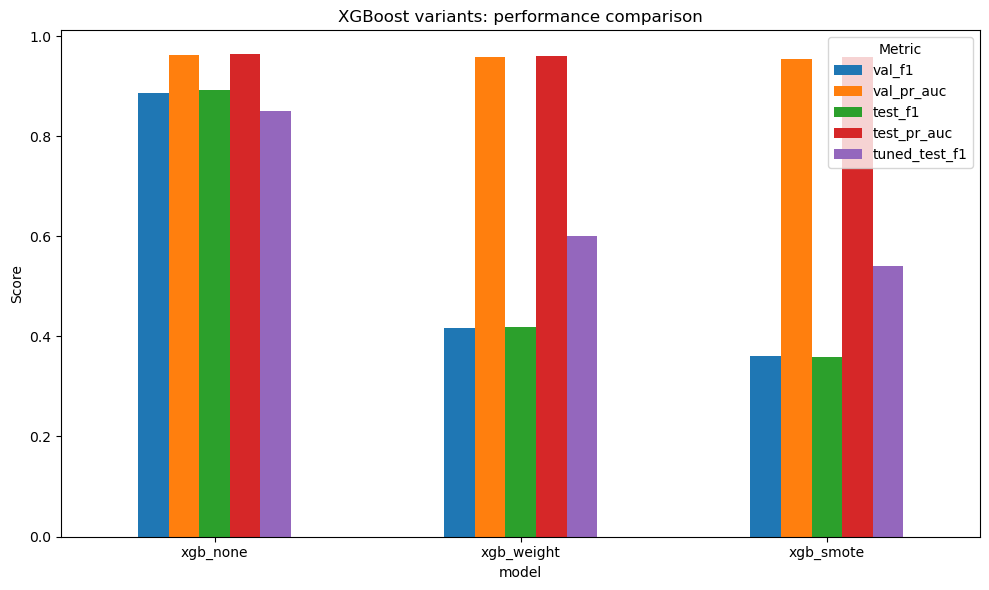

In [74]:
import matplotlib.pyplot as plt

plot_df = comparison_df.set_index("model")[[
    "val_f1",
    "val_pr_auc",
    "test_f1",
    "test_pr_auc",
    "tuned_test_f1"
]]

plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("XGBoost variants: performance comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

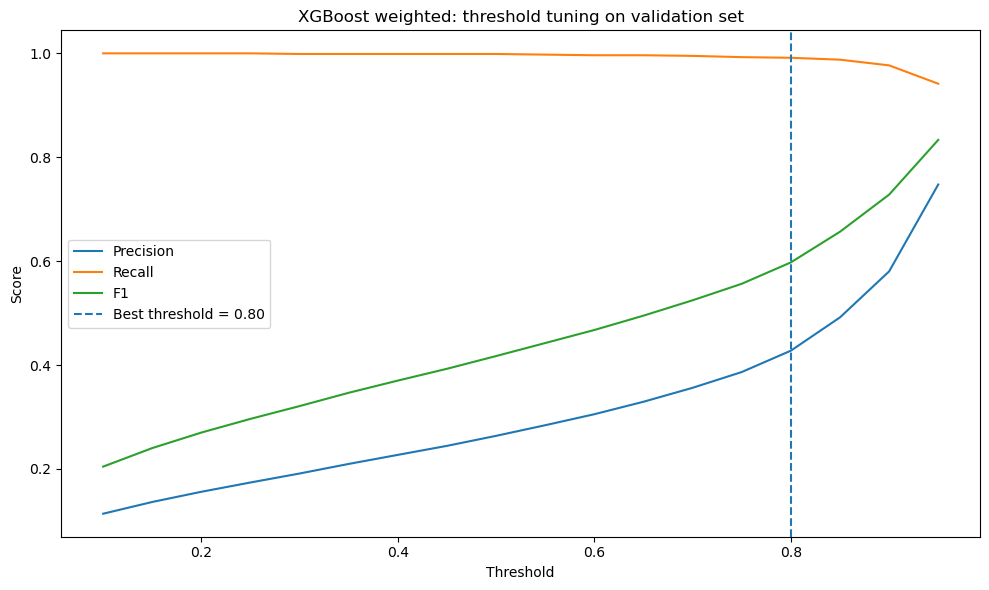

In [75]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(threshold_results_weight["threshold"], threshold_results_weight["precision"], label="Precision")
plt.plot(threshold_results_weight["threshold"], threshold_results_weight["recall"], label="Recall")
plt.plot(threshold_results_weight["threshold"], threshold_results_weight["f1"], label="F1")

plt.axvline(best_threshold_weight, linestyle="--", label=f"Best threshold = {best_threshold_weight:.2f}")
plt.title("XGBoost weighted: threshold tuning on validation set")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()

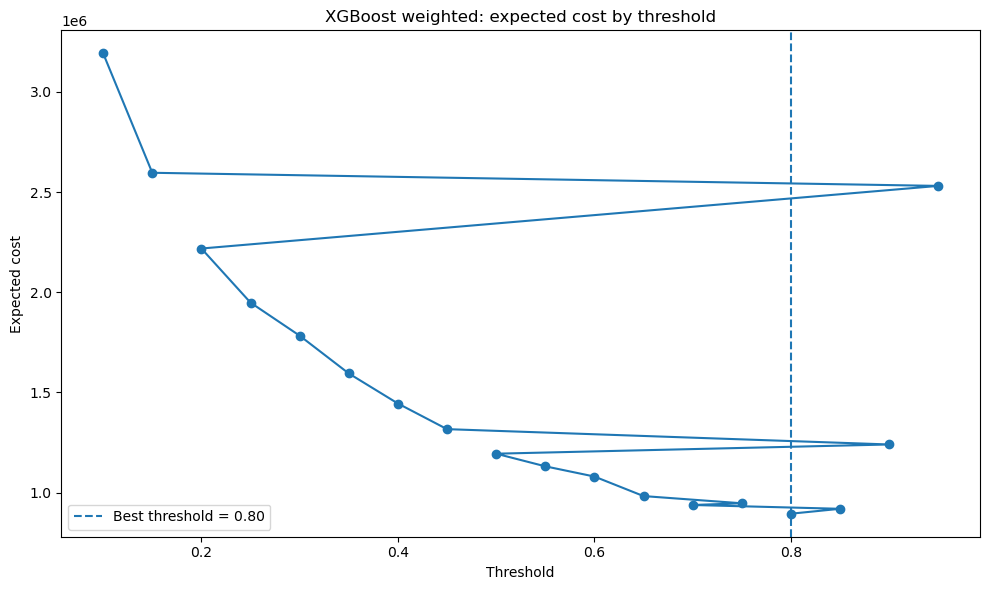

In [76]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(cost_df_weight["threshold"], cost_df_weight["expected_cost"], marker="o")

plt.axvline(best_threshold_weight, linestyle="--", label=f"Best threshold = {best_threshold_weight:.2f}")
plt.title("XGBoost weighted: expected cost by threshold")
plt.xlabel("Threshold")
plt.ylabel("Expected cost")
plt.legend()
plt.tight_layout()
plt.show()

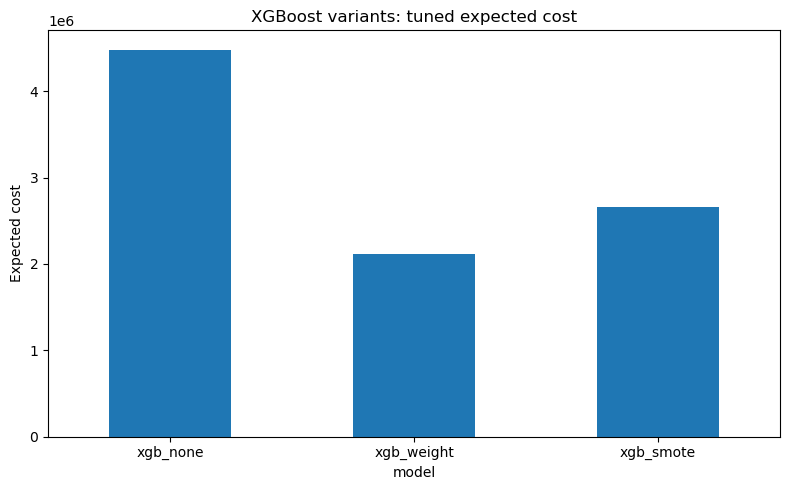

In [77]:
import matplotlib.pyplot as plt

cost_plot_df = comparison_df.set_index("model")[["tuned_expected_cost"]]

cost_plot_df.plot(kind="bar", figsize=(8, 5))
plt.title("XGBoost variants: tuned expected cost")
plt.ylabel("Expected cost")
plt.xticks(rotation=0)
plt.legend().remove()
plt.tight_layout()
plt.show()